### Simulação Discreta - Fila de Carros
> Semelhante ao exemplo no slide, vamos fazer uma simulação de fila (discreta) para os carros chegando e saindo em um semáforo.

In [1]:
import time
import matplotlib.pyplot as plt

In [2]:
# =========================================================
# 1. PARÂMETROS DA SIMULAÇÃO (Configurável para a aula)
# =========================================================

tempo_total = 30           # Duração total da simulação (segundos)
tempo_troca_sinal = 10     # O semáforo troca a cada X segundos
chegadas_por_segundo = 2   # Quantos carros entram na fila por segundo
saida_por_segundo = 3      # Quantos carros passam por segundo (se VERDE)
fila = 0                   # Fila inicial

# Controle do Semáforo
sinal = "VERMELHO"
tempo_no_sinal = 0

historico_tempo = []
historico_fila = []

In [3]:
# =========================================================
# 2. EXECUÇÃO DA SIMULAÇÃO
# =========================================================

print("--- INÍCIO DA SIMULAÇÃO ---")

for t in range(tempo_total):

    # Se deu o tempo limite do semáforo, inverte o sinal e zera o contador
    if tempo_no_sinal == tempo_troca_sinal:
        if sinal == "VERMELHO":
            sinal = "VERDE"
        else:
            sinal = "VERMELHO"
        tempo_no_sinal = 0

    # Lógica de saída de carros
    if sinal == "VERMELHO":
        saida = 0
    else:
        saida = saida_por_segundo

    # Equação de Estado: Fila nova = Fila antiga + Chegadas - Saídas
    fila = fila + (chegadas_por_segundo - saida)

    # Regra: Fila não fica negativa
    if fila < 0:
        fila = 0

    # Salva dados para o gráfico
    historico_tempo.append(t)
    historico_fila.append(fila)

    # Imprime os logs em tempo real
    print(f"Tempo: {t:02d}s | Sinal: {sinal:8s} | Fila: {fila:2d} carros")
    time.sleep(0.5)

    # Conta +1 segundo para o sinal atual
    tempo_no_sinal += 1

print("--- FIM DA SIMULAÇÃO ---")

--- INÍCIO DA SIMULAÇÃO ---
Tempo: 00s | Sinal: VERMELHO | Fila:  2 carros
Tempo: 01s | Sinal: VERMELHO | Fila:  4 carros
Tempo: 02s | Sinal: VERMELHO | Fila:  6 carros
Tempo: 03s | Sinal: VERMELHO | Fila:  8 carros
Tempo: 04s | Sinal: VERMELHO | Fila: 10 carros
Tempo: 05s | Sinal: VERMELHO | Fila: 12 carros
Tempo: 06s | Sinal: VERMELHO | Fila: 14 carros
Tempo: 07s | Sinal: VERMELHO | Fila: 16 carros
Tempo: 08s | Sinal: VERMELHO | Fila: 18 carros
Tempo: 09s | Sinal: VERMELHO | Fila: 20 carros
Tempo: 10s | Sinal: VERDE    | Fila: 19 carros
Tempo: 11s | Sinal: VERDE    | Fila: 18 carros
Tempo: 12s | Sinal: VERDE    | Fila: 17 carros
Tempo: 13s | Sinal: VERDE    | Fila: 16 carros
Tempo: 14s | Sinal: VERDE    | Fila: 15 carros
Tempo: 15s | Sinal: VERDE    | Fila: 14 carros
Tempo: 16s | Sinal: VERDE    | Fila: 13 carros
Tempo: 17s | Sinal: VERDE    | Fila: 12 carros
Tempo: 18s | Sinal: VERDE    | Fila: 11 carros
Tempo: 19s | Sinal: VERDE    | Fila: 10 carros
Tempo: 20s | Sinal: VERMELHO | F

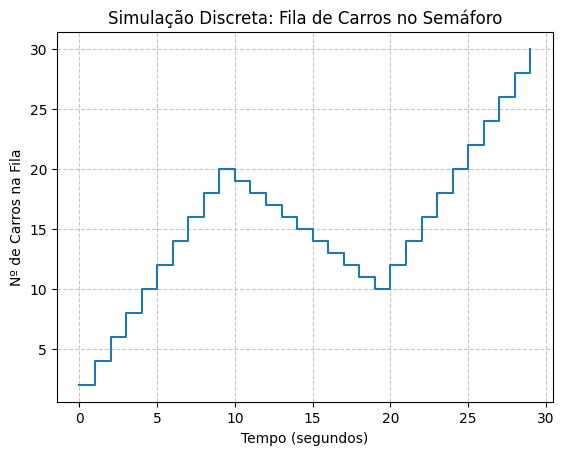

In [4]:
# =========================================================
# 3. GERAÇÃO DO GRÁFICO (Visualização Discreta)
# =========================================================

plt.step(historico_tempo, historico_fila, where='post')
plt.title("Simulação Discreta: Fila de Carros no Semáforo")
plt.xlabel("Tempo (segundos)")
plt.ylabel("Nº de Carros na Fila")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

### Simulação Contínua - Velocidade do Carro

> Agora que simulamos a fila (discreta), vamos simular a velocidade do carro chegando no semáforo (contínua).

#### Regras:
* Se o sinal for VERMELHO, o carro deve pisar no freio e a velocidade cai.
* Se o sinal for VERDE, o carro pisa no acelerador e a velocidade aumenta.
* A velocidade não pode ser **menor que zero**, nem **maior que 20 m/s²**.

#### Fórmula:
> Velocidade = Velocidade + Taxa * dT

Onde:
* **Velocidade** é a atual e dada em m/s².
* **Taxa** é a taxa de aceleração em m/s².
* **dT** é o tempo mas agora em função contínua em 0.5 segundos (float).
---

Para essa simulação considere a velocidade do carro de **aceleração de 2 m/s²** e **frenagem de -3 m/s²**.


In [9]:
# =========================================================
# 1. PARÂMETROS DA SIMULAÇÃO CONTÍNUA
# =========================================================
dt = 0.5                  # Passo de tempo contínuo (0.1 segundo)
tempo_total = 30          # Tempo total (segundos)
tempo_troca_sinal = 10    # O sinal troca a cada 10s

velocidade = 0.0            # Velocidade inicial do carro (m/s)
velocidade_maxima = 20.0    # Limite de velocidade (m/s)

# Taxas de variação contínua (Aceleração em m/s²)
frenagem = -3.0             # Desaceleração no vermelho
aceleracao = 2.0            # Aceleração no verde

# Controle do Semáforo
sinal = "VERMELHO"
tempo_no_sinal = 0

historico_tempo = []
historico_velocidade = []

In [10]:
# =========================================================
# 2. EXECUÇÃO DA SIMULAÇÃO
# =========================================================
t = 0.0
while t < tempo_total:

    # 1. Lógica do Semáforo
    if tempo_no_sinal >= tempo_troca_sinal:
        if sinal == "VERMELHO":
            sinal = "VERDE"
        else:
            sinal = "VERMELHO"
        tempo_no_sinal = 0.0

    # 2. Define a Taxa de Variação (Aceleração)
    if sinal == "VERMELHO":
        taxa = frenagem
    else:
        taxa = aceleracao

    # 3. Equação Contínua: Fórmula de velocidade
    velocidade = velocidade + taxa * dt

    # Limites físicos do sistema
    if velocidade < 0.0:
        velocidade = 0.0
    if velocidade > velocidade_maxima:
        velocidade = taxa

    # Guarda os dados
    historico_tempo.append(t)
    historico_velocidade.append(velocidade)

    # Imprime os logs a cada meio segundo
    print(
      f"Tempo: {t:04.1f}s | Sinal: {sinal:8s} | Velocidade:"
      f" {velocidade:5.1f} m/s"
    )
    time.sleep(0.5)

    # Avança o tempo em pequenos passos (dt)
    t = t + dt
    tempo_no_sinal = tempo_no_sinal + dt

Tempo: 00.0s | Sinal: VERMELHO | Velocidade:   0.0 m/s
Tempo: 00.5s | Sinal: VERMELHO | Velocidade:   0.0 m/s
Tempo: 01.0s | Sinal: VERMELHO | Velocidade:   0.0 m/s
Tempo: 01.5s | Sinal: VERMELHO | Velocidade:   0.0 m/s
Tempo: 02.0s | Sinal: VERMELHO | Velocidade:   0.0 m/s
Tempo: 02.5s | Sinal: VERMELHO | Velocidade:   0.0 m/s
Tempo: 03.0s | Sinal: VERMELHO | Velocidade:   0.0 m/s
Tempo: 03.5s | Sinal: VERMELHO | Velocidade:   0.0 m/s
Tempo: 04.0s | Sinal: VERMELHO | Velocidade:   0.0 m/s
Tempo: 04.5s | Sinal: VERMELHO | Velocidade:   0.0 m/s
Tempo: 05.0s | Sinal: VERMELHO | Velocidade:   0.0 m/s
Tempo: 05.5s | Sinal: VERMELHO | Velocidade:   0.0 m/s
Tempo: 06.0s | Sinal: VERMELHO | Velocidade:   0.0 m/s
Tempo: 06.5s | Sinal: VERMELHO | Velocidade:   0.0 m/s
Tempo: 07.0s | Sinal: VERMELHO | Velocidade:   0.0 m/s
Tempo: 07.5s | Sinal: VERMELHO | Velocidade:   0.0 m/s
Tempo: 08.0s | Sinal: VERMELHO | Velocidade:   0.0 m/s
Tempo: 08.5s | Sinal: VERMELHO | Velocidade:   0.0 m/s
Tempo: 09.

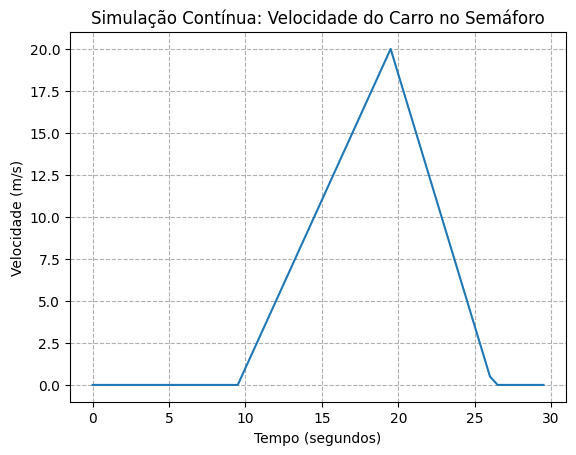

In [11]:
# =========================================================
# 3. GERAÇÃO DO GRÁFICO (Linha Contínua)
# =========================================================
plt.plot(historico_tempo, historico_velocidade)
plt.title("Simulação Contínua: Velocidade do Carro no Semáforo")
plt.xlabel("Tempo (segundos)")
plt.ylabel("Velocidade (m/s)")
plt.grid(True, linestyle="--")
plt.show()

Pergunta para refletir:
> Se o tempo de 0.5s em **float** define um sistema **contínuo**, se eu colocar em 1 segundo **int** ele não seria **discreto**?